## setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./data/all/extracted_data.csv")
df

,name,thoracic_width,cardiac_width,ctr,gender,brightness
0,jsrt-JPCLN001,389.0,184.0,0.473,NaN,196.9
1,jsrt-JPCLN002,362.0,222.0,0.613,NaN,160.2
2,jsrt-JPCLN003,371.0,184.0,0.496,NaN,206.9
3,jsrt-JPCLN004,377.0,172.0,0.456,NaN,184.3
4,jsrt-JPCLN005,373.0,234.0,0.627,NaN,211.2
...,...,...,...,...,...,...
1082,shenzhen-M-1557,336.0,NaN,NaN,M,166.5
1083,shenzhen-M-1559,349.0,NaN,NaN,M,144.7
1084,shenzhen-M-1561,428.0,NaN,NaN,M,160.6
1085,shenzhen-M-1564,338.0,NaN,NaN,M,173.3


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
thoracic_width,1087.0,369.253910,41.919592,247.000,338.0000,366.000,396.0000,500.000
cardiac_width,383.0,199.621410,25.392732,141.000,182.0000,199.000,216.0000,291.000
ctr,383.0,0.502522,0.068341,0.347,0.4535,0.498,0.5495,0.747
brightness,1087.0,157.971849,24.540580,85.200,140.1500,155.300,175.4000,215.600


## ctr distrobution

In [5]:
def plot_ctr_histogram(df, range_step, show_normal_range=True):
    step = range_step
    ctr_min = df['ctr'].min()
    ctr_max = df['ctr'].max()
    
    start = 0.50 + step * np.floor((ctr_min - 0.50) / step)
    stop = 0.50 + step * np.ceil((ctr_max - 0.50) / step)
    bin_edges = np.arange(start, stop, step)
    
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    sns.histplot(df['ctr'].dropna(), bins=bin_edges, color='orange')

    if show_normal_range:
        plt.axvline(x=0.42, color='blue', linestyle='--', label='Normal Aralık')
        plt.axvline(x=0.50, color='blue', linestyle='--')

    plt.xticks(bin_edges)
    plt.title('KTO Dağılımı')
    plt.xlabel('KTO')
    plt.ylabel('Sayı')
    if show_normal_range:
        plt.legend()
    plt.show()

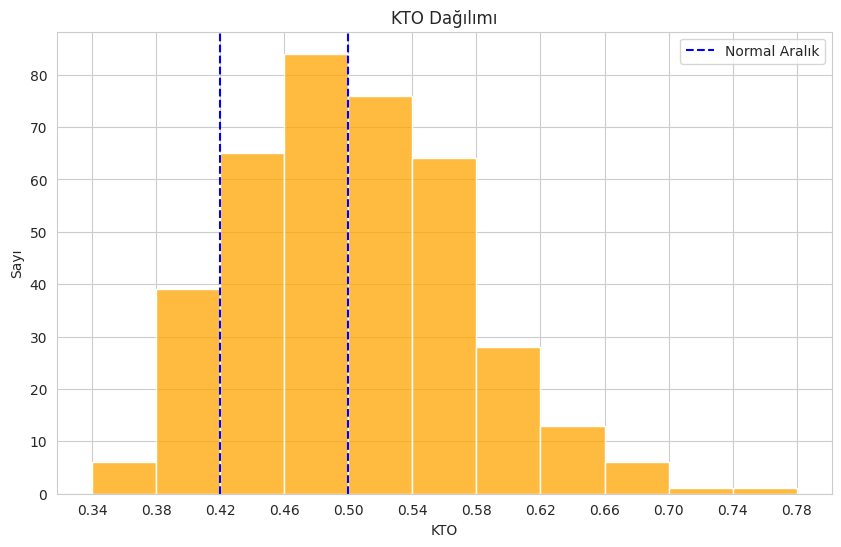

In [37]:
plot_ctr_histogram(df, 0.04, show_normal_range=True)

## gender counts

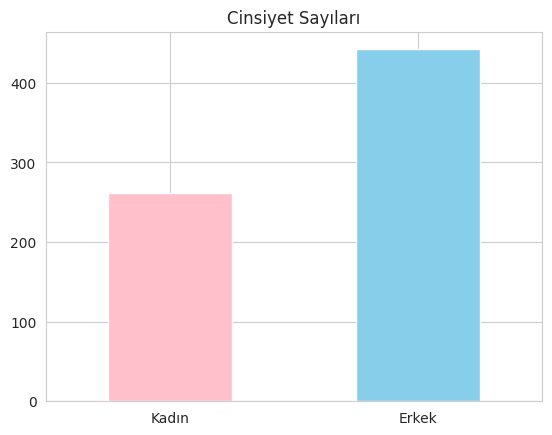

In [7]:
gender_counts = df['gender'].value_counts(dropna=False)[['F', 'M']]
gender_counts.plot(kind='bar', color=['pink', 'skyblue'])
plt.title('Cinsiyet Sayıları')
plt.xlabel('')
plt.ylabel('')
plt.xticks(ticks=[0, 1], labels=['Kadın', 'Erkek'], rotation=0)
plt.show()

## brightness

In [25]:
def plot_brightness_histogram(df, range_step, xlim=(0, 255), ctr_only=False):
    step = range_step
    bin_edges = np.arange(0, 256 + step, step)
    
    if ctr_only:
        df = df.dropna(subset=['ctr'])
    brightness_values = df['brightness'].dropna()

    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    sns.histplot(brightness_values, bins=bin_edges, color='gray')
    plt.xticks(bin_edges)
    plt.xlim(xlim)
    plt.title('Parlaklık Dağılımı')
    plt.xlabel('Parlaklık')
    plt.ylabel('Sayı')
    plt.show()

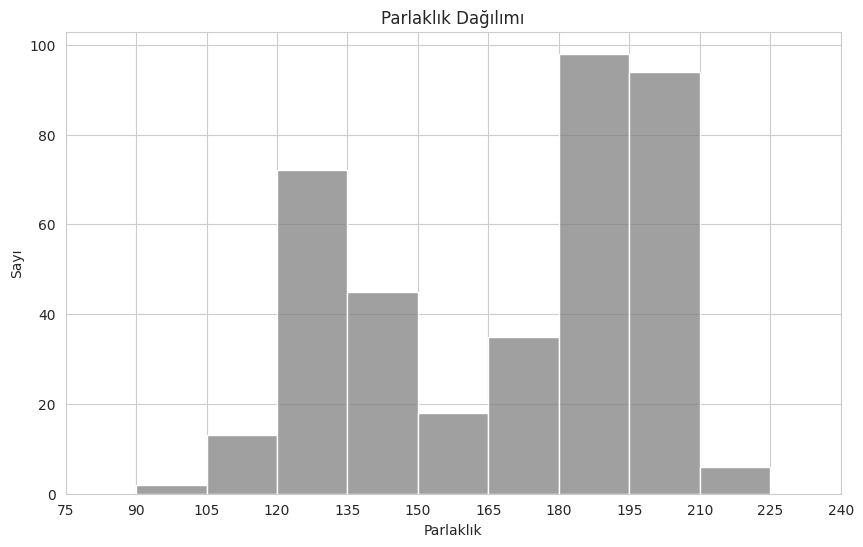

In [41]:
plot_brightness_histogram(df, 15, xlim=(75, 240), ctr_only=True)

## correlational analysis

In [32]:
def plot_brightness_ctr_correlation(df, xlim=(0, 255), ylim=(0,1), x_gap=15, y_gap=0.1):
    df_valid = df.dropna(subset=['ctr', 'brightness'])

    correlation = df_valid['brightness'].corr(df_valid['ctr'])
    print(f'Correlation coefficient: {correlation:.3f}')

    plt.figure(figsize=(8, 6))
    plt.scatter(df_valid['brightness'], df_valid['ctr'], alpha=0.5)
    plt.title('Parlaklık ve CTR Arasındaki Korelasyon')
    plt.xlabel('Parlaklık')
    plt.ylabel('CTR')

    plt.xlim(xlim)
    plt.ylim(ylim)

    def frange(start, stop, step):
        values = []
        while start <= stop:
            values.append(start)
            start = round(start + step, 10)
        return values

    plt.xticks(range(xlim[0], xlim[1] + 1, x_gap))
    y_ticks = [round(i, 2) for i in frange(ylim[0], ylim[1], y_gap)]
    plt.yticks(y_ticks)

    plt.grid(True)
    plt.tight_layout()
    plt.show()

Correlation coefficient: -0.500


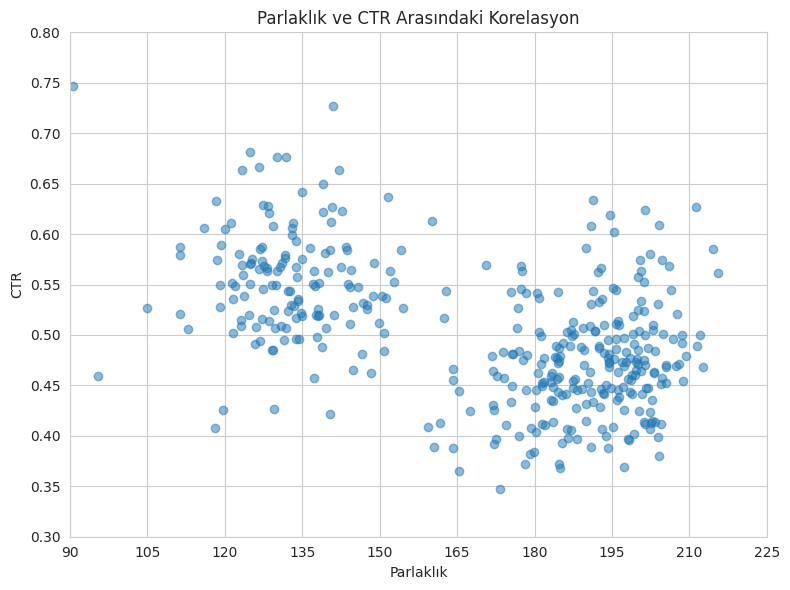

In [43]:
plot_brightness_ctr_correlation(df, xlim=(90, 225), ylim=(0.3,0.8), x_gap=15, y_gap=0.05)

## new